<a href="https://colab.research.google.com/github/Man980/py_project/blob/main/oni_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# COPY MY PROJECT INTO COLAB INSTEAD TRAINING DIRECTLY FROM DRIVE

In [ ]:
import shutil, os

# Copy dataset
if not os.path.exists('/content/Dataset'):
    print("Copying dataset...")
    shutil.copytree(
        '/content/drive/MyDrive/Mask_Remover_APP/Dataset',
        '/content/Dataset'
    )
    print("Dataset done!")

# Copy code files
if not os.path.exists('/content/Mask_Remover_APP'):
    print("Copying code files...")
    shutil.copytree(
        '/content/drive/MyDrive/Mask_Remover_APP',
        '/content/Mask_Remover_APP',
        ignore=shutil.ignore_patterns('Dataset', 'CheckPoint4', '.git')  # skip heavy folders
    )
    print("Code files done!")

Copying dataset...
Dataset done!
Copying code files...
Code files done!


In [ ]:
import sys
sys.path.insert(0, '/content/Mask_Remover_APP')

import os
for f in ['train.py', 'dataloader.py', 'models.py', 'utils.py', 'blocks.py']:
    exists = os.path.exists(f'/content/Mask_Remover_APP/{f}')
    print(f"{f}: {'✓' if exists else '✗ MISSING'}")

train.py: ✓
dataloader.py: ✓
models.py: ✓
utils.py: ✓
blocks.py: ✓


# Load dataloader

In [ ]:
import os
import sys
import importlib.util

print("Current directory:", os.getcwd())
print("Python executable:", sys.executable)
print("sys.path contains project:",
      "/content/Mask_Remover_APP" in sys.path)

print("Find spec:",
      importlib.util.find_spec("dataloader"))

Current directory: /content
Python executable: /usr/bin/python3
sys.path contains project: True
Find spec: None


# Unet_training Stage

In [ ]:
# Unet Training
import sys
#sys.path.append('/content/drive/MyDrive/Mask_Remover_APP')
sys.path.insert(0, '/content/Mask_Remover_APP')  # local disk is faster than Drive

import numpy as np
import time
import random
import os
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torchvision import utils
from torch.utils.data import Dataset, DataLoader

import dataloader
from dataloader import *
from models import *
from utils import *

random_seed = 777
rand_fix(random_seed)

device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")

#dataset_dir = "/content/drive/MyDrive/Mask_Remover_APP/Dataset/"
#dataset_dir_made = '/content/drive/MyDrive/Mask_Remover_APP/Dataset'
dataset_dir      = "/content/Dataset/"       # local disk = faster reads
dataset_dir_made = "/content/Dataset"

save_dir     = "/content/drive/MyDrive/Mask_Remover_APP/CheckPoint4/"  # save to Drive so checkpoints persist
num_workers  = 2      # parallel image loading (was 0)
batch_size   = 8
num_epochs   = 20
lr           = 0.001

transform       = trans(mode='normal')
transform_mask  = trans(mode='mask')
transform_test  = trans(mode='test')

train_dataset    = FaceMask(dataset_dir, dataset_dir_made, transform, transform_mask)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, num_workers=num_workers)

test_dataset    = FaceMask(dataset_dir, dataset_dir_made, transform, transform_test=transform_test, test=True)
test_dataloader = DataLoader(test_dataset, batch_size=8,
                             shuffle=False, num_workers=num_workers)

sample   = next(iter(test_dataloader))
test_img = sample['test_img'].to(device)
show_img = sample['show_img']

loss = nn.BCELoss()

#--------------------------------------------------------------------------------------------
# SPECIAL BLOCK (USED TO CONTINUE THE PROCESS STOPPED WHILE THE RUNTIME WAS STOPPED)
#--------------------------------------------------------------------------------------------

checkpoint_dir = '/content/drive/MyDrive/Mask_Remover_APP/CheckPoint4/'
checkpoints    = sorted([f for f in os.listdir(checkpoint_dir) if f.endswith('.pt')])

if checkpoints:
    latest = os.path.join(checkpoint_dir, checkpoints[-1])
    print(f"Resuming from: {latest}")

    checkpoint  = torch.load(latest, map_location=device)
    start_epoch = checkpoint['epoch']  # will resume from next epoch

    model = Unet().to(device)
    model.apply(weights_init)              # MUST apply spectral norm BEFORE loading state dict
    model.load_state_dict(checkpoint['model_state_dict'])

    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer.load_state_dict(checkpoint['model_opt'])

    print(f"Resuming from epoch {start_epoch + 1}/{num_epochs}")

else:
    # No checkpoint found, start fresh
    print("No checkpoint found, starting from scratch")
    start_epoch = 0

    model = Unet().to(device)
    model.apply(weights_init)
    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.5, 0.999))

#++++++++++++++++++++++++++++++++++ END OF SPECIAL BLOCK +++++++++++++++++++++++++++++++++++++

# Keep-alive thread: prints every 15 minutes so the cell stays active
import threading
def keep_alive():
    while True:
        time.sleep(900)  # 15 minutes
        print("⏳ Still training...", time.strftime("%H:%M:%S"))
thread = threading.Thread(target=keep_alive, daemon=True)
thread.start()

Start = time.time()
print("Starting Training Loop...")
Loss_list = []

for epoch in range(start_epoch, num_epochs):
    print("Epoch {}/{}".format(epoch + 1, num_epochs))
    print("-" * 10)
    start = time.time()

    face_masked    = None
    face_cloth     = None
    face_surgical  = None
    mask           = None
    mask_cloth     = None
    mask_surgical  = None

    for i, sample in enumerate(train_dataloader, 0):
        face_masked, mask     = sample['W_mask'], sample['mask']
        face_cloth, face_surgical = sample['cloth'], sample['surgical']
        mask_cloth, mask_surgical = sample['mask_cloth'], sample['mask_surgical']
        batch_size = mask.size(0)

        face_masked   = face_masked.to(device)
        mask          = mask.to(device)
        face_cloth    = face_cloth.to(device)
        face_surgical = face_surgical.to(device)
        mask_cloth    = mask_cloth.to(device)
        mask_surgical = mask_surgical.to(device)

        optimizer.zero_grad()

        output_m = model(face_masked)
        output_c = model(face_cloth)
        output_s = model(face_surgical)

        Loss_m = loss(output_m, mask)
        Loss_c = loss(output_c, mask_cloth)
        Loss_s = loss(output_s, mask_surgical)

        Loss = Loss_m + Loss_c + Loss_s
        Loss_list.append(Loss.item())
        Loss.backward()
        optimizer.step()

        if (i % 100 == 0):
            print("[{:d}/{:d}] Loss : {:.4f}".format(i, len(train_dataloader), Loss.item()))

    # Save checkpoint to Drive after every epoch so progress is never lost
    save_checkpoint({
        'epoch'            : epoch + 1,
        'model_state_dict' : model.state_dict(),
        'model_opt'        : optimizer.state_dict()
    }, save_dir, epoch + 1)

    print("=" * 100)
    print('Time taken by epoch: {:.0f}h {:.0f}m {:.0f}s'.format(
        ((time.time() - start) // 60) // 60,
        (time.time() - start) // 60,
        (time.time() - start) % 60))
    print()

    # Visual results block (commented out for speed — uncomment to see mask predictions per epoch)
    '''
    with torch.no_grad():
        result    = model(face_masked).cpu()
        result_s  = model(face_surgical).cpu()
        result_c  = model(face_cloth).cpu()
        test_result = model(test_img).cpu()
        m = mask.cpu()
        s = mask_surgical.cpu()
        c = mask_cloth.cpu()
        sample      = []
        test_sample = []
        for i in range(batch_size):
            sample.extend([m[i], result[i], s[i], result_s[i], c[i], result_c[i]])
        for i in range(8):
            test_sample.append(test_result[i])
        result_img      = utils.make_grid(sample, padding=2, normalize=True, nrow=6)
        test_result_img = utils.make_grid(test_sample, padding=0, normalize=True, nrow=1)
        utils.save_image(result_img,      "./result_unet/result-{}epoch.png".format(epoch + 1))
        utils.save_image(test_result_img, "./result_unet/test_result-{}epoch.png".format(epoch + 1))
    '''

print("Training is finished")
hour = ((time.time() - Start) // 60) // 60
print('Time taken by num_epochs: {:.0f}h {:.0f}m {:.0f}s'.format(
    hour,
    (time.time() - Start) - hour * 60,
    (time.time() - Start) % 60))


In [ ]:
device = torch.device("cuda:0")
print(f"Fixed device: {device}")

# LOAD THE TRAIN FILE HERE CAUSE I CAN'T RUN IT TRHOUGH : PYTHON TRAIN.PY

In [ ]:
import numpy as np
import time
import random
import os
import matplotlib.pyplot as plt
from IQA_pytorch import SSIM

import torch
import torch.optim as optim
import torchvision.models as vmodels
from torchvision import utils
from torch.utils.data import Dataset, DataLoader

from dataloader import *
from models import *
from utils import *

random_seed = 777

rand_fix(random_seed)

device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")

vgg = VGG19(requires_grad=False).to(device)

epoch = 16
dataset_dir = "./Dataset/"
save_dir = "/content/drive/MyDrive/Mask_Remover_APP/CheckPoint3/"
model_dir = '/content/drive/MyDrive/Mask_Remover_APP/CheckPoint3/checkpoint-{}.pt'.format(epoch)
Epoch = 19
bin_model_dir = '/content/drive/MyDrive/Mask_Remover_APP/CheckPoint4/checkpoint-{}.pt'.format(Epoch)

num_workers = 0
batch_size = 4
num_epochs = 50
lr_G = 0.001
lr_D = 0.003
real_label = 1.
fake_label = 0.
alpha = 1
beta = 1
gamma = 100

transform = trans(mode = 'normal')
#transform_mask = trans(mode = 'mask')

train_dataset = FaceMask(dataset_dir, transform)
train_dataloader = DataLoader(train_dataset, batch_size = batch_size,
                             shuffle = True, num_workers = num_workers)

test_dataset = FaceMask(dataset_dir, transform, test = True)
test_dataloader = DataLoader(test_dataset, batch_size = int(len(test_dataset) / 4),
                            shuffle = False, num_workers = num_workers)

sample = iter(test_dataloader)
sample1 = next(sample)
sample2 = next(sample)
sample3 = next(sample)
sample4 = next(sample)

test_img1 = sample1['test_img'].to(device)
test_img2 = sample2['test_img'].to(device)
test_img3 = sample3['test_img'].to(device)
test_img4 = sample4['test_img'].to(device)

'''
checkpoint = torch.load(model_dir)
netG_state_dict = checkpoint['netG_state_dict']
netD_state_dict = checkpoint['netD_state_dict']
optG_state_dict = checkpoint['G_opt']
optD_state_dict = checkpoint['D_opt']
'''
netG = Generator().to(device)
netG.apply(weights_init)
#netG.load_state_dict(netG_state_dict)

netD = Discriminator().to(device)
netD.apply(weights_init)
#netD.load_state_dict(netD_state_dict)


checkpoint = torch.load(bin_model_dir)
bin_model_state_dict = checkpoint['model_state_dict']
bin_model = Unet().to(device)
bin_model.apply(weights_init)
bin_model.load_state_dict(bin_model_state_dict)
bin_model.eval()

test_bin_img1 = bin_model(test_img1)
test_img_cat1 = torch.cat([test_img1, test_bin_img1], dim = 1)
test_bin_img2 = bin_model(test_img2)
test_img_cat2 = torch.cat([test_img2, test_bin_img2], dim = 1)
test_bin_img3 = bin_model(test_img3)
test_img_cat3 = torch.cat([test_img3, test_bin_img3], dim = 1)
test_bin_img4 = bin_model(test_img4)
test_img_cat4 = torch.cat([test_img4, test_bin_img4], dim = 1)

# Batch unique regroupant les 4 échantillons de test (utilisé lors de l'évaluation en fin d'epoch)
test_img_all = torch.cat([test_img1, test_img2, test_img3, test_img4], dim = 0)
test_img_cat_all = torch.cat([test_img_cat1, test_img_cat2, test_img_cat3, test_img_cat4], dim = 0)

optim_G = optim.Adam(netG.parameters(), lr = lr_G, betas = (0.5, 0.999))
optim_D = optim.Adam(netD.parameters(), lr = lr_D, betas = (0.5, 0.999))

dataloader = train_dataloader

criterion = nn.L1Loss()
gan_loss = nn.BCELoss()
ssim = SSIM()

G_losses = []
D_losses = []
shape_losses = []
perceptual_losses = []
SSIM_losses = []

Start = time.time()
print("Starting Training Loop...")

for epoch in range(num_epochs):
    j = 1
    netG.train()
    netD.train()
    print("Epoch {}/{}".format(epoch + 1, num_epochs))
    print("-" * 10)
    start = time.time()

    face_masked = None
    face_unmasked = None
    for i, sample in enumerate(dataloader, 0):
        face_masked, face_unmasked = sample['W_mask'], sample['WO_mask']
        batch_size = face_masked.size(0)

        face_masked = face_masked.to(device)
        face_unmasked = face_unmasked.to(device)

        optim_D.zero_grad()
        optim_G.zero_grad()

        #Update D with GAN_Loss
        binaryzation_mask = bin_model(face_masked)
        binaryzation_mask = binaryzation_mask.to(device)
        face_masked_cat = torch.cat([face_masked, binaryzation_mask], dim = 1)

        output = netG(face_masked_cat)
        fake = netD(output)
        real = netD(face_unmasked)

        Real_label = torch.full((real.size()), real_label, dtype = torch.float, device = device)
        Fake_label = torch.full((fake.size()), fake_label, dtype = torch.float, device = device)
        D_Loss = (gan_loss(real, Real_label) + gan_loss(fake, Fake_label)) * alpha
        # Loss 설정시 L(pre, target) 왼쪽은 prediction 오른쪽은 target
        D_losses.append(D_Loss.item())

        #Update G with GAN_Loss
        G_Loss = (gan_loss(fake, Real_label)) * alpha
        G_losses.append(G_Loss.item())
        G_Loss.backward(retain_graph=True)

        #Update G with Shape_Loss
        Shape_Loss = criterion(output, face_unmasked) * beta
        shape_losses.append(Shape_Loss.item())

        gt1_relu3_4, gt1_relu4_4, gt1_relu5_4 = vgg(face_unmasked)
        output_relu3_4, output_relu4_4, output_relu5_4 = vgg(output)

        perceptual_loss = criterion(gt1_relu3_4, output_relu3_4) + criterion(gt1_relu4_4, output_relu4_4) + criterion(gt1_relu5_4, output_relu5_4)
        perceptual_losses.append(perceptual_loss.item())

        SSIM_loss = ssim(output, face_unmasked)
        SSIM_losses.append(SSIM_loss.item())

        Loss = (D_Loss + G_Loss) * alpha + Shape_Loss * beta + (perceptual_loss + SSIM_loss) * gamma
        Loss.backward()
        optim_D.step()
        optim_G.step()

        if (i % 1000 == 0):
                print("[{:d}/{:d}] D_ganL:{:.4f}     G_ganL:{:.4f}     Shape_L:{:.4f}".
             format(i, len(dataloader), D_Loss.item(), G_Loss.item(), Shape_Loss.item()))


    save_checkpoint({
            'epoch' : epoch + 1,
            'netG_state_dict' : netG.state_dict(),
            'netD_state_dict' : netD.state_dict(),
            'G_opt' : optim_G.state_dict(),
            'D_opt' : optim_D.state_dict()
    }, save_dir, epoch + 1)

    print("="*100)
    _time = (time.time() - start) // 60
    hour = _time // 60
    minutes = hour % 60
    print('Time taken by epoch: {:.0f}h {:.0f}m {:.0f}s'.format(hour, minutes, (time.time() - start) % 60))
    print()

    with torch.no_grad():
        netG.eval()
        result = netG(face_masked_cat).cpu()
        test_result = netG(test_img_cat_all).cpu()

        inp = face_masked.cpu()
        oup = face_unmasked.cpu()

        sample = []
        test_sample = []

        for i in range(inp.size(0)):
            sample.extend([inp[i], result[i]])
        for i in range(test_img_all.size(0)):
            test_sample.extend([test_img_all[i].cpu(), test_result[i]])

        result_img = utils.make_grid(sample, padding = 2,
                                        normalize = True, nrow = 2)
        test_result_img = utils.make_grid(test_sample, padding = 0,
                                        normalize = True, nrow = 2)
        utils.save_image(result_img, "./result3/result-{}epoch.png".format(epoch + 1))
        utils.save_image(test_result_img, "./result3/test_result-{}epoch.png".format(epoch + 1))

print("Training is finished")
_time = (time.time() - start) // 60
hour = _time // 60
minutes = hour % 60
print('Time taken by num_epochs: {:.0f}h {:.0f}m {:.0f}s'.format(hour, minutes, (time.time() - Start) % 60))

TypeError: 'NoneType' object is not callable

In [ ]:
!pip install IQA_pytorch

# This version of code pick up where the colab runtime left off

In [ ]:
import sys
sys.path.insert(0, '/content/Mask_Remover_APP')  # local disk is faster than Drive

import numpy as np
import time
import random
import os
import matplotlib.pyplot as plt
from IQA_pytorch import SSIM

import torch
import torch.optim as optim
import torchvision.models as vmodels
from torchvision import utils
from torch.utils.data import Dataset, DataLoader

from dataloader import *
from models import *
from utils import *

random_seed = 777
rand_fix(random_seed)

device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")

vgg = VGG19(requires_grad=False).to(device)

dataset_dir   = "/content/Dataset/"                                                         # local disk = faster reads
save_dir      = "/content/drive/MyDrive/Mask_Remover_APP/CheckPoint3/"                     # save to Drive so checkpoints persist
bin_model_dir = '/content/drive/MyDrive/Mask_Remover_APP/CheckPoint4/checkpoint-20.pt'     # your finished Unet (epoch 20)

num_workers = 2
batch_size  = 4
num_epochs  = 50
lr_G        = 0.001
lr_D        = 0.003
real_label  = 1.
fake_label  = 0.
alpha       = 1
beta        = 1
gamma       = 100

transform = trans(mode='normal')

train_dataset    = FaceMask(dataset_dir, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, num_workers=num_workers)

test_dataset    = FaceMask(dataset_dir, transform=transform, test=True)
test_dataloader = DataLoader(test_dataset, batch_size=int(len(test_dataset) / 4),
                             shuffle=False, num_workers=num_workers)

sample  = iter(test_dataloader)
sample1 = next(sample)
sample2 = next(sample)
sample3 = next(sample)
sample4 = next(sample)

test_img1 = sample1['test_img'].to(device)
test_img2 = sample2['test_img'].to(device)
test_img3 = sample3['test_img'].to(device)
test_img4 = sample4['test_img'].to(device)

# Load finished Unet (binarization model) — frozen, not trained further
ckpt_unet = torch.load(bin_model_dir, map_location=device)
bin_model  = Unet().to(device)
bin_model.apply(weights_init)
bin_model.load_state_dict(ckpt_unet['model_state_dict'])
bin_model.eval()

# Precompute test image concatenations (masked image + binary mask from Unet)
with torch.no_grad():
    test_bin_img1  = bin_model(test_img1)
    test_img_cat1  = torch.cat([test_img1, test_bin_img1], dim=1)
    test_bin_img2  = bin_model(test_img2)
    test_img_cat2  = torch.cat([test_img2, test_bin_img2], dim=1)
    test_bin_img3  = bin_model(test_img3)
    test_img_cat3  = torch.cat([test_img3, test_bin_img3], dim=1)
    test_bin_img4  = bin_model(test_img4)
    test_img_cat4  = torch.cat([test_img4, test_bin_img4], dim=1)

# Batch unique regroupant les 4 échantillons de test (utilisé lors de l'évaluation en fin d'epoch)
test_img_all     = torch.cat([test_img1, test_img2, test_img3, test_img4], dim=0)
test_img_cat_all = torch.cat([test_img_cat1, test_img_cat2, test_img_cat3, test_img_cat4], dim=0)

criterion = nn.L1Loss()
gan_loss  = nn.BCELoss()
ssim      = SSIM()

G_losses          = []
D_losses          = []
shape_losses      = []
perceptual_losses = []
SSIM_losses       = []

#--------------------------------------------------------------------------------------------
# SPECIAL BLOCK (USED TO CONTINUE THE PROCESS STOPPED WHILE THE RUNTIME WAS STOPPED)
#--------------------------------------------------------------------------------------------

checkpoint_dir = '/content/drive/MyDrive/Mask_Remover_APP/CheckPoint3/'
checkpoints    = [f for f in os.listdir(checkpoint_dir) if f.endswith('.pt')]

if checkpoints:
    latest = os.path.join(checkpoint_dir, checkpoints[-1])
    print(f"Resuming from: {latest}")

    ckpt        = torch.load(latest, map_location=device)
    start_epoch = ckpt['epoch']  # will resume from next epoch

    netG = Generator().to(device)
    netG.apply(weights_init)                        # MUST apply spectral norm BEFORE loading state dict
    netG.load_state_dict(ckpt['netG_state_dict'])

    netD = Discriminator().to(device)
    netD.apply(weights_init)                        # MUST apply spectral norm BEFORE loading state dict
    netD.load_state_dict(ckpt['netD_state_dict'])

    optim_G = optim.Adam(netG.parameters(), lr=lr_G, betas=(0.5, 0.999))
    optim_D = optim.Adam(netD.parameters(), lr=lr_D, betas=(0.5, 0.999))
    optim_G.load_state_dict(ckpt['G_opt'])
    optim_D.load_state_dict(ckpt['D_opt'])

    print(f"Resuming from epoch {start_epoch + 1}/{num_epochs}")

else:
    # No checkpoint found, start fresh
    print("No checkpoint found, starting from scratch")
    start_epoch = 0

    netG = Generator().to(device)
    netG.apply(weights_init)

    netD = Discriminator().to(device)
    netD.apply(weights_init)

    optim_G = optim.Adam(netG.parameters(), lr=lr_G, betas=(0.5, 0.999))
    optim_D = optim.Adam(netD.parameters(), lr=lr_D, betas=(0.5, 0.999))

#++++++++++++++++++++++++++++++++++ END OF SPECIAL BLOCK +++++++++++++++++++++++++++++++++++++

# Keep-alive thread: prints every 15 minutes so the cell stays active
import threading
def keep_alive():
    while True:
        time.sleep(900)  # 15 minutes
        print("⏳ Still training...", time.strftime("%H:%M:%S"))
thread = threading.Thread(target=keep_alive, daemon=True)
thread.start()

# Create result folder if it doesn't exist
os.makedirs('./result3', exist_ok=True)

dataloader = train_dataloader

Start = time.time()
print("Starting Training Loop...")

for epoch in range(start_epoch, num_epochs):
    j = 1
    netG.train()
    netD.train()
    print("Epoch {}/{}".format(epoch + 1, num_epochs))
    print("-" * 10)
    start = time.time()

    face_masked   = None
    face_unmasked = None

    for i, sample in enumerate(dataloader, 0):
        face_masked, face_unmasked = sample['W_mask'], sample['WO_mask']
        batch_size = face_masked.size(0)

        face_masked   = face_masked.to(device)
        face_unmasked = face_unmasked.to(device)

        optim_D.zero_grad()

        # Update D with GAN_Loss
        binaryzation_mask = bin_model(face_masked)
        binaryzation_mask = binaryzation_mask.to(device)
        face_masked_cat   = torch.cat([face_masked, binaryzation_mask], dim=1)

        output = netG(face_masked_cat)
        fake   = netD(output.detach())   # detach so D gradients don't flow into G
        real   = netD(face_unmasked)

        Real_label = torch.full(real.size(), real_label, dtype=torch.float, device=device)
        Fake_label = torch.full(fake.size(), fake_label, dtype=torch.float, device=device)

        D_Loss = (gan_loss(real, Real_label) + gan_loss(fake, Fake_label)) * alpha
        # Loss 설정시 L(pre, target) 왼쪽은 prediction 오른쪽은 target
        D_losses.append(D_Loss.item())
        D_Loss.backward()               # D backward first
        optim_D.step()                  # D step first

        # Update G with all losses
        optim_G.zero_grad()
        fake      = netD(output)        # re-run D on output (without detach) for G update
        G_Loss    = (gan_loss(fake, Real_label)) * alpha
        G_losses.append(G_Loss.item())

        Shape_Loss = criterion(output, face_unmasked) * beta
        shape_losses.append(Shape_Loss.item())

        gt1_relu3_4,    gt1_relu4_4,    gt1_relu5_4    = vgg(face_unmasked)
        output_relu3_4, output_relu4_4, output_relu5_4 = vgg(output)

        perceptual_loss = (criterion(gt1_relu3_4,   output_relu3_4) +
                           criterion(gt1_relu4_4,   output_relu4_4) +
                           criterion(gt1_relu5_4,   output_relu5_4))
        perceptual_losses.append(perceptual_loss.item())

        SSIM_loss = ssim(output, face_unmasked)
        SSIM_losses.append(SSIM_loss.item())

        G_total_loss = G_Loss + Shape_Loss * beta + (perceptual_loss + SSIM_loss) * gamma
        G_total_loss.backward()         # G backward
        optim_G.step()                  # G step

        if (i % 1000 == 0):
            print("[{:d}/{:d}] D_ganL:{:.4f}     G_ganL:{:.4f}     Shape_L:{:.4f}".
                  format(i, len(dataloader), D_Loss.item(), G_Loss.item(), Shape_Loss.item()))

    # Save checkpoint to Drive after every epoch so progress is never lost
    save_checkpoint({
        'epoch'           : epoch + 1,
        'netG_state_dict' : netG.state_dict(),
        'netD_state_dict' : netD.state_dict(),
        'G_opt'           : optim_G.state_dict(),
        'D_opt'           : optim_D.state_dict()
    }, save_dir, epoch + 1)

    print("=" * 100)
    _time   = (time.time() - start) // 60
    hour    = _time // 60
    minutes = _time % 60
    print('Time taken by epoch: {:.0f}h {:.0f}m {:.0f}s'.format(hour, minutes, (time.time() - start) % 60))
    print()

    with torch.no_grad():
        netG.eval()
        result      = netG(face_masked_cat).cpu()
        test_result = netG(test_img_cat_all).cpu()

        inp = face_masked.cpu()

        sample      = []
        test_sample = []

        for i in range(inp.size(0)):
            sample.extend([inp[i], result[i]])
        for i in range(test_img_all.size(0)):
            test_sample.extend([test_img_all[i].cpu(), test_result[i]])

        result_img      = utils.make_grid(sample,      padding=2, normalize=True, nrow=2)
        test_result_img = utils.make_grid(test_sample, padding=0, normalize=True, nrow=2)
        utils.save_image(result_img,      "./result3/result-{}epoch.png".format(epoch + 1))
        utils.save_image(test_result_img, "./result3/test_result-{}epoch.png".format(epoch + 1))

print("Training is finished")
_time   = (time.time() - Start) // 60
hour    = _time // 60
minutes = _time % 60
print('Time taken by num_epochs: {:.0f}h {:.0f}m {:.0f}s'.format(hour, minutes, (time.time() - Start) % 60))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:09<00:00, 59.0MB/s]


Resuming from: /content/drive/MyDrive/Mask_Remover_APP/CheckPoint3/checkpoint-24.pt
Resuming from epoch 25/50
Starting Training Loop...
Epoch 25/50
----------
[0/1246] D_ganL:1.0889     G_ganL:1.0941     Shape_L:0.0405
⏳ Still training... 17:02:29
⏳ Still training... 17:17:29
⏳ Still training... 17:32:29
⏳ Still training... 17:47:29
⏳ Still training... 18:02:29
⏳ Still training... 18:17:29
⏳ Still training... 18:32:29
⏳ Still training... 18:47:29
⏳ Still training... 19:02:29


In [ ]:
!pip install IQA_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 2.8 MB/s eta 0:00:00


# TEST

Saving 6847-fr-balaclava-face-mask-black-3q-on-model_0.jpg to 6847-fr-balaclava-face-mask-black-3q-on-model_0 (1).jpg


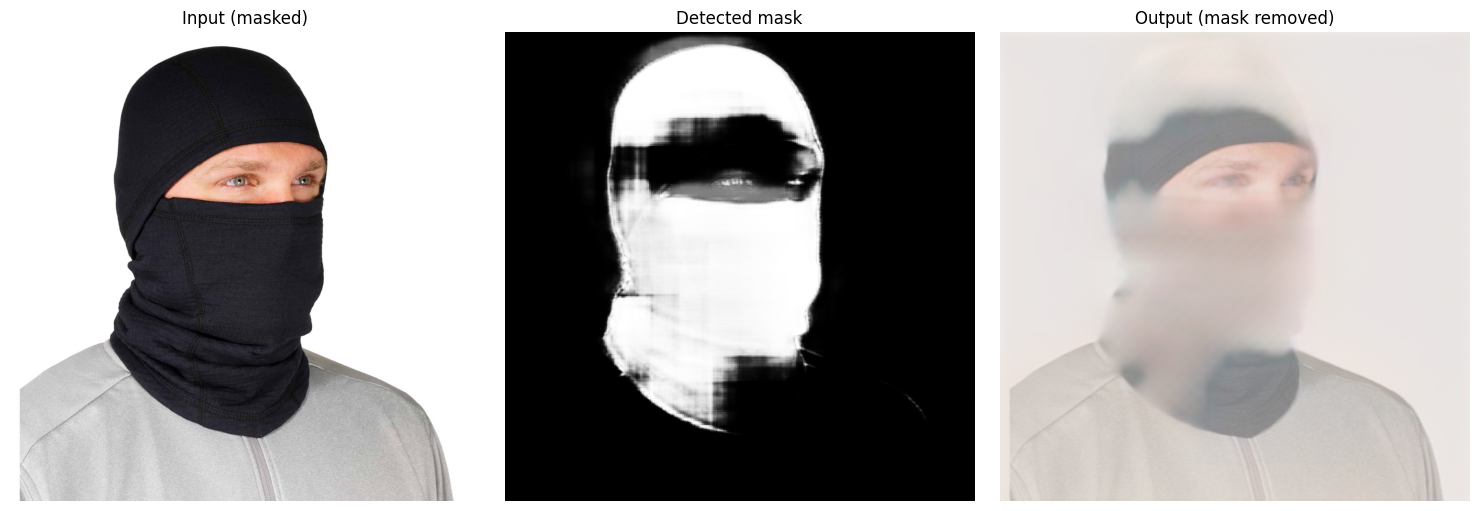

Saved to Drive!


In [11]:
import sys
sys.path.insert(0, '/content/Mask_Remover_APP')

import torch
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

from models import *
from utils import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# ---- Load Unet (binarization model) ----
bin_checkpoint = torch.load('/content/drive/MyDrive/Mask_Remover_APP/CheckPoint4/checkpoint-20.pt', map_location=device)
#bin_checkpoint = torch.load('/content/drive/MyDrive/Mask_Remover_APP/CheckPoint4/checkpoint-9.pt', map_location=device)
bin_model = Unet().to(device)
bin_model.apply(weights_init)
bin_model.load_state_dict(bin_checkpoint['model_state_dict'])
bin_model.eval()


# ---- Load Generator ----
#gen_checkpoint = torch.load('/content/drive/MyDrive/Mask_Remover_APP/CheckPoint3/checkpoint-50.pt', map_location=device)
gen_checkpoint = torch.load('/content/drive/MyDrive/Mask_Remover_APP/CheckPoint3/checkpoint-20.pt', map_location=device)
netG = Generator().to(device)
netG.apply(weights_init)
netG.load_state_dict(gen_checkpoint['netG_state_dict'])
netG.eval()

# ---- Upload and test image ----
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

transform = trans(mode='normal')
img = Image.open(img_path).convert('RGB')
img_tensor = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    bin_output = bin_model(img_tensor)
    img_cat    = torch.cat([img_tensor, bin_output], dim=1)
    output     = netG(img_cat).cpu()

# Tanh output [-1,1] → rescale to [0,1]
output_img = (output.squeeze(0) + 1) / 2
output_img = output_img.permute(1, 2, 0).numpy().clip(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title('Input (masked)')
axes[0].axis('off')

axes[1].imshow(bin_output.squeeze().cpu().numpy(), cmap='gray')
axes[1].set_title('Detected mask')
axes[1].axis('off')

axes[2].imshow(output_img)
axes[2].set_title('Output (mask removed)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Mask_Remover_APP/test_result.png', dpi=150)
plt.show()
print("Saved to Drive!")

In [4]:
import os
path = '/content/CheckPoint4/'
if os.path.exists(path):
    print(os.listdir(path))
else:
    print("Folder doesn't exist — checkpoints are lost")

Folder doesn't exist — checkpoints are lost


In [ ]:
import os
print(os.path.exists('/content/Dataset'))  # should print True

# TRAIN FILE